# Surface Crack Detection using CNN

# Model Evaluation

## Objectives

- Load the trained model
- Evaluate model performance
- Generate predictions
- Plot Confusion Matrix
- Print Classification Report

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
IMAGE_SIZE = (120,120)
BATCH_SIZE = 32

dataset_path = "../data"

In [3]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = validation_dataset.class_names

Found 40000 files belonging to 2 classes.
Using 8000 files for validation.


In [4]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [5]:
model = tf.keras.models.load_model(
    "../models/crack_detection_model.keras"
)

In [6]:
loss, accuracy = model.evaluate(validation_dataset)

print(f"Validation Accuracy: {accuracy:.4f}")

250/250 [==============================] - 25s 100ms/step - loss: 0.0048 - accuracy: 0.9989
Validation Accuracy: 0.9989


In [7]:
predictions = model.predict(validation_dataset)

predicted_labels = (
    predictions > 0.5
).astype("int32").flatten()

250/250 [==============================] - 33s 131ms/step


In [8]:
true_labels = np.concatenate(
    [labels for images, labels in validation_dataset],
    axis=0
)

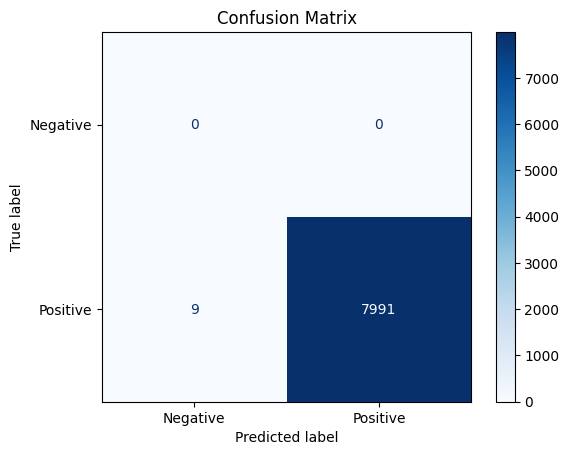

In [9]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [10]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         0
    Positive       1.00      1.00      1.00      8000

    accuracy                           1.00      8000
   macro avg       0.50      0.50      0.50      8000
weighted avg       1.00      1.00      1.00      8000



c:\Users\vinit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vinit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vinit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

1/1 [==============================] - 0s 288ms/step


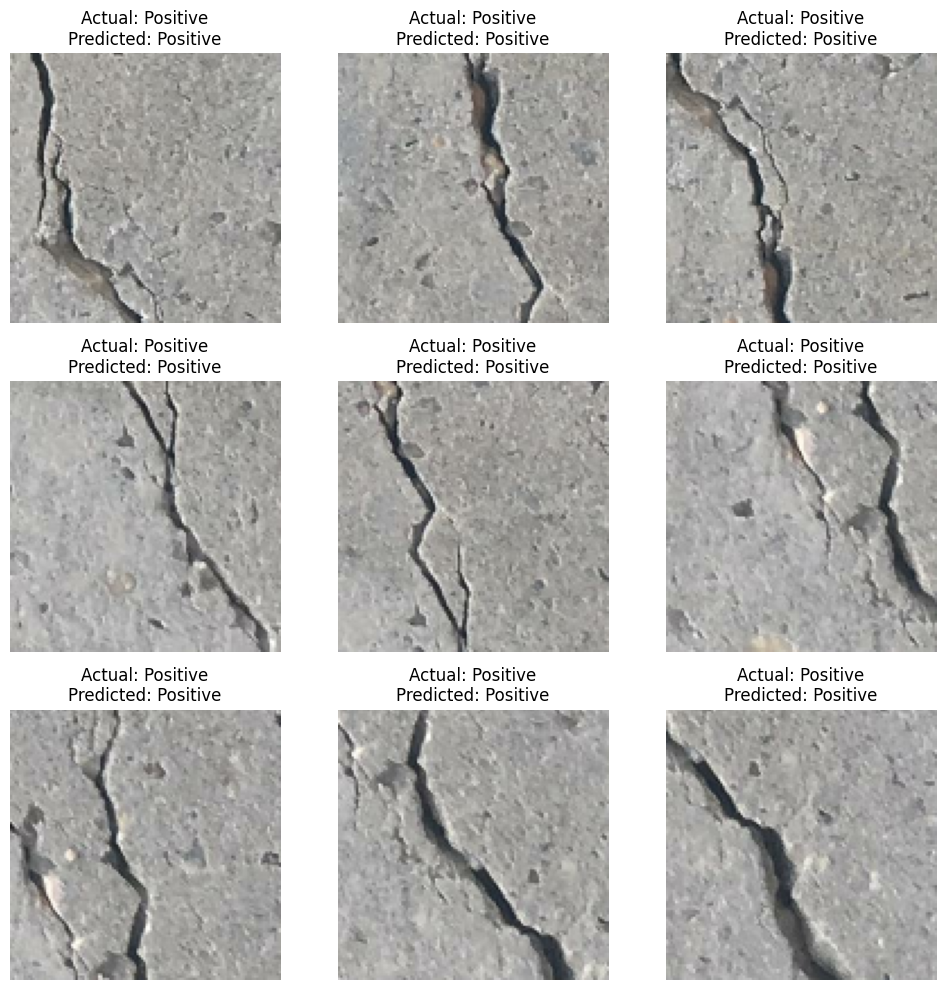

In [11]:
plt.figure(figsize=(10,10))

for images, labels in validation_dataset.take(1):

    predictions = model.predict(images)

    predicted = (
        predictions > 0.5
    ).astype("int32").flatten()

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy())

        plt.title(
            f"Actual: {class_names[labels[i]]}\nPredicted: {class_names[predicted[i]]}"
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

# Summary

Completed:

- Loaded trained CNN model
- Evaluated model
- Generated predictions
- Plotted confusion matrix
- Generated classification report
- Visualized sample predictions